In [67]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

### **importing the data**

In [70]:
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,
                            "tarekmasryo/football-matches-20242025-top-5-leagues",
                            "football_matches_2024_2025.csv"
                            )
print("description of data columns")
df.info()

print("first five rows")
df.head()


C:\Users\tassili\AppData\Local\Temp\ipykernel_20408\2345638612.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,


description of data columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   competition_code  1941 non-null   object
 1   competition_name  1941 non-null   object
 2   season            1941 non-null   object
 3   match_id          1941 non-null   int64 
 4   matchday          1941 non-null   int64 
 5   stage             1941 non-null   object
 6   status            1941 non-null   object
 7   date_utc          1941 non-null   object
 8   referee           1941 non-null   object
 9   home_team_id      1941 non-null   int64 
 10  home_team         1941 non-null   object
 11  away_team_id      1941 non-null   int64 
 12  away_team         1941 non-null   object
 13  fulltime_home     1941 non-null   int64 
 14  fulltime_away     1941 non-null   int64 
 15  halftime_home     1941 non-null   int64 
 16  halftime_away     1941 non-null 

,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5


### **percentage of winning at home**

In [16]:
#method 1
winning_at_home_proba = ((df["match_outcome"] == "Home Win").mean()) * 100
print(f"the chance of a team winnig in home is : {winning_at_home_proba}")

#method 2
place_of_win_count = df["match_outcome"].value_counts(normalize=True)
print(f"the chance of winning at home is : {place_of_win_count["Home Win"] * 100}")

the chance of a team winnig in home is : 42.86450283359093
the chance of winning at home is : 42.86450283359093


### now lets plot it

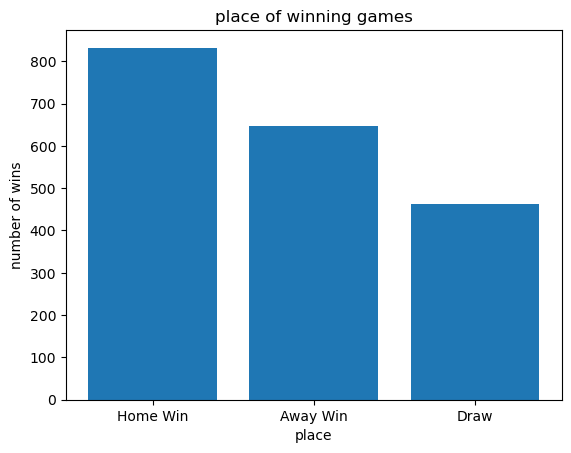

In [40]:
place_of_win = df["match_outcome"].value_counts()
plt.figure()
plt.bar(place_of_win.index,place_of_win.values)
plt.title("place of winning games")
plt.xlabel("place")
plt.ylabel("number of wins")
plt.show()

## next we gonna see, where majority of the goals are scored, either its in the first half or second

In [38]:
#first we add a column, which is second half goals 

df["firsthalf_goals"] = df["halftime_home"] + df["halftime_away"]
df["secondhalf_goals"] = df["fulltime_home"] + df["fulltime_away"] - df["firsthalf_goals"]
df["fulltime_goals"] = df["firsthalf_goals"] + df["secondhalf_goals"]
goals_df = df[df["fulltime_goals"] > 0].copy()
goals_df["firsthalf_percentage"] = goals_df["firsthalf_goals"] / goals_df["fulltime_goals"] 
goals_df["secondhalf_percentage"] = goals_df["secondhalf_goals"] / goals_df["fulltime_goals"]

print(f"average number of goals in the game : {df["fulltime_goals"].mean()}")
print(f"average number of goals in first half : {df["firsthalf_goals"].mean()}")
print(f"average number of goals in second half : {df["secondhalf_goals"].mean()}")

#method 1
print(f"percentage of goals ina first half / alltime : {goals_df["firsthalf_percentage"].mean() * 100}")
print(f"percentage of goals in second half / alltime : {goals_df["secondhalf_percentage"].mean() * 100}")

#method2

print(f"percentage of goals in first half : {(df["firsthalf_goals"].sum() / df["fulltime_goals"].sum()) * 100}")
print(f"percentage of goals in second half : {(df["secondhalf_goals"].sum() / df["fulltime_goals"].sum()) * 100 }")


average number of goals in the game : 2.8758371973209687
average number of goals in first half : 1.287995878413189
average number of goals in second half : 1.5878413189077796
percentage of goals ina first half / alltime : 44.10057113224781
percentage of goals in second half / alltime : 55.89942886775218
percentage of goals in first half : 44.78681476173414
percentage of goals in second half : 55.21318523826585


### now we plot it

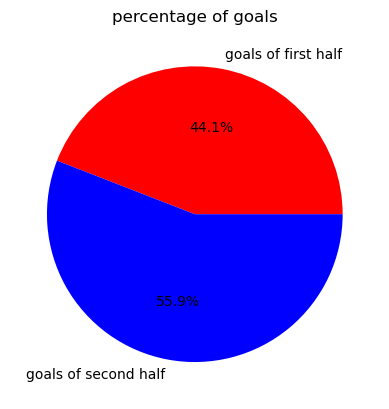

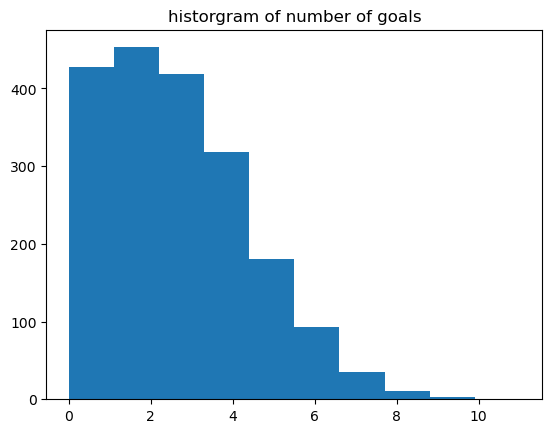

In [36]:
plt.figure()
my_labels = ["goals of first half","goals of second half"]
array_of_perc = np.array([goals_df["firsthalf_percentage"].mean(),goals_df["secondhalf_percentage"].mean()])
plt.title("percentage of goals")
plt.pie(array_of_perc,
        labels=my_labels,
        autopct="%1.1f%%",
        colors=["red","blue"])
plt.show()

plt.figure()
plt.title("historgram of number of goals")
plt.hist(df["fulltime_goals"])
plt.show()

## **studying goals per league** 

In [57]:
leagues = df.groupby("competition_name")
league_goal_means = leagues["total_goals"].mean()
print(league_goal_means)

league_differences_mean = leagues["goal_difference"].mean()
print(league_differences_mean)

competition_name
Bundesliga               3.133987
La Liga                  2.618421
Ligue 1                  2.977124
Premier League           2.934211
Serie A                  2.560526
UEFA Champions League    3.328042
Name: total_goals, dtype: float64
competition_name
Bundesliga               0.127451
La Liga                  0.286842
Ligue 1                  0.238562
Premier League           0.092105
Serie A                  0.118421
UEFA Champions League    0.417989
Name: goal_difference, dtype: float64


## now we plot it

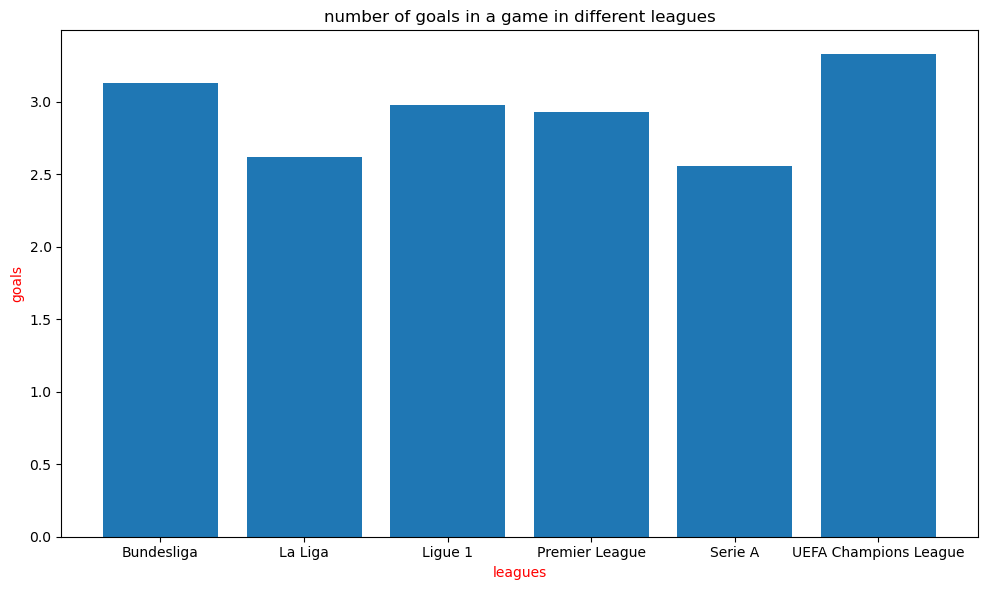

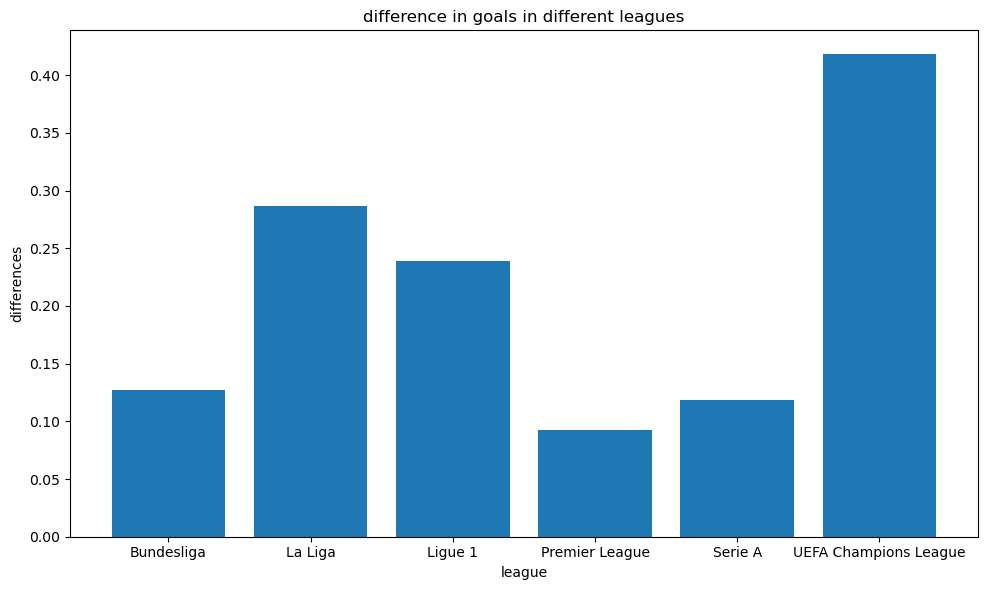

In [66]:
plt.figure(figsize=(10,6))
plt.title("number of goals in a game in different leagues")
plt.bar(league_goal_means.index,league_goal_means.values)
plt.xlabel("leagues",color="red")
plt.ylabel("goals",color="red")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.title("difference in goals in different leagues")
plt.bar(league_differences_mean.index,league_differences_mean.values)
plt.xlabel("league")
plt.ylabel("differences")
plt.tight_layout()
plt.show()

## **TEAMS**

## now we're gonna study the teams, first we check which wins the most games

In [ ]:
## first we create an additionnal column, winning team
def winner(row):
    if row["match_outcome"] == "Home Win":
        return row["home_team"]
    elif row["match_outcome"] == "Away Win":
        return row["away_team"]
    else:
        return None

# df["winning_team"] = np.where(
#     df["match_outcome"] == "Home Win", df["home_team"],
#     np.where(df["match_outcome"] == "Away Win", df["away_team"],None)
# )
df["winner"] = df.apply(winner,axis=1)
df.iloc[0:5]

,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,home_team,away_team_id,away_team,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,referee_id,winner
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,Manchester United FC,63,Fulham FC,1,0,0,0,1,1,Home Win,3,0,1,Manchester United FC
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,Ipswich Town FC,64,Liverpool FC,0,2,0,0,-2,2,Away Win,0,3,2,Liverpool FC
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,Arsenal FC,76,Wolverhampton Wanderers FC,2,0,1,0,2,2,Home Win,3,0,3,Arsenal FC
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,Everton FC,397,Brighton & Hove Albion FC,0,3,0,1,-3,3,Away Win,0,3,4,Brighton & Hove Albion FC
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,Newcastle United FC,340,Southampton FC,1,0,1,0,1,1,Home Win,3,0,5,Newcastle United FC


In [97]:
#then we group by teams
winning_teams = df.groupby("winner")
print(winning_teams.size().sort_values(ascending=False).iloc[0:10])

winner
Paris Saint-Germain FC      37
FC Barcelona                37
Real Madrid CF              35
FC Internazionale Milano    34
Liverpool FC                33
FC Bayern München           33
Arsenal FC                  29
Club Atlético de Madrid     28
Aston Villa FC              27
Atalanta BC                 26
dtype: int64


### now we plot


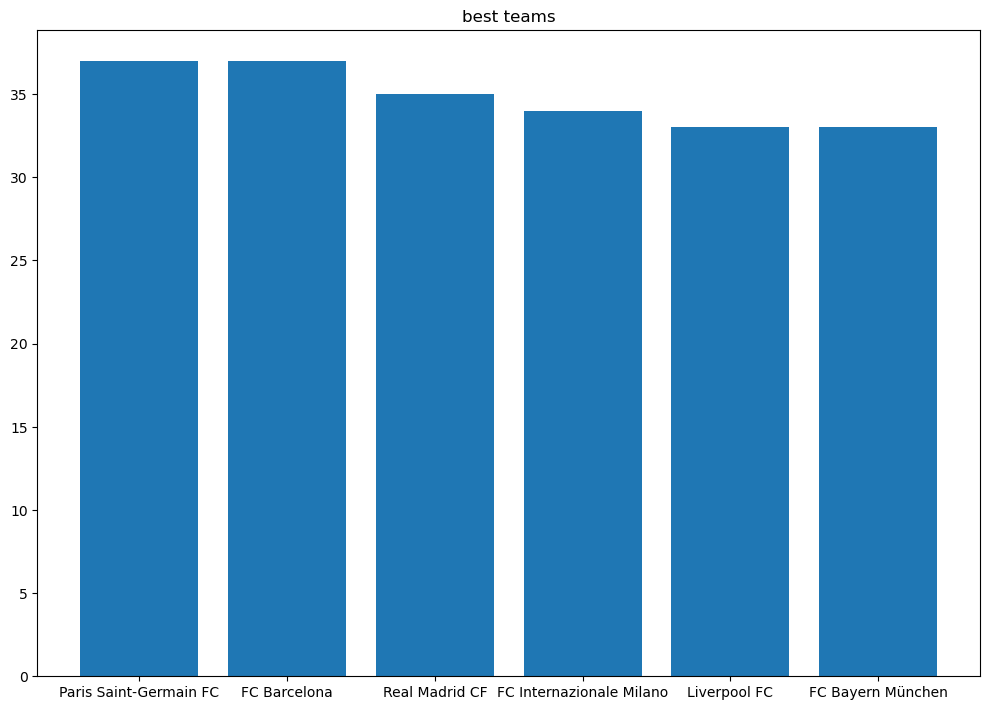

In [135]:
plt.figure(figsize=(10,7))
winning_teams_size = winning_teams.size()
best_10_teams = winning_teams.size().sort_values(ascending=False).iloc[0:6]
plt.bar(best_10_teams.index,best_10_teams.values)
plt.tight_layout()
plt.title("best teams")
plt.show()

## now we gonna study the number of goals scored in a match with respect to the matchday

In [108]:
## first we groupy by the match days
df["total_goals"] = df["fulltime_home"] + df["fulltime_away"]
match_days = df.groupby("matchday")
match_days["total_goals"].mean().head()

matchday
0    5.000000
1    2.840909
2    3.102273
3    3.000000
4    2.833333
Name: total_goals, dtype: float64

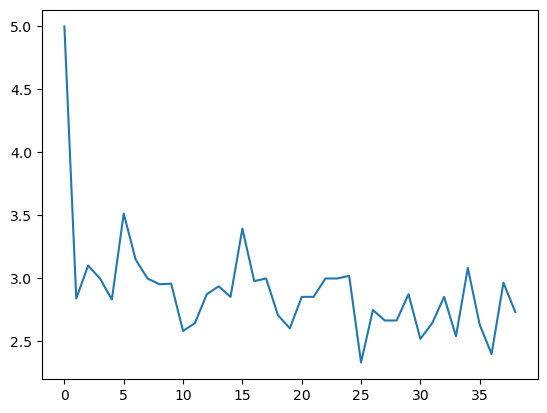

In [110]:
plt.figure()
plt.plot(match_days["total_goals"].mean())
plt.show()

#### as we can see the more we advance in te tounrnaments, the less goals we see each matchday

### now we gonna see the teams who scored the most and see if it has a relation with the teams that won the most matches

In [126]:
home_teams = df.groupby("home_team")
away_teams = df.groupby("away_team")

best_scoring_teams = pd.concat([home_teams["fulltime_home"].sum().sort_values(ascending=True),away_teams["fulltime_away"].sum()])
best_scoring_teams = best_scoring_teams.groupby(level=0).sum()
print(best_scoring_teams.sort_values(ascending=False).head())

FC Barcelona                145
Paris Saint-Germain FC      134
FC Bayern München           130
Real Madrid CF              111
FC Internazionale Milano    105
dtype: int64


### now lets plot it

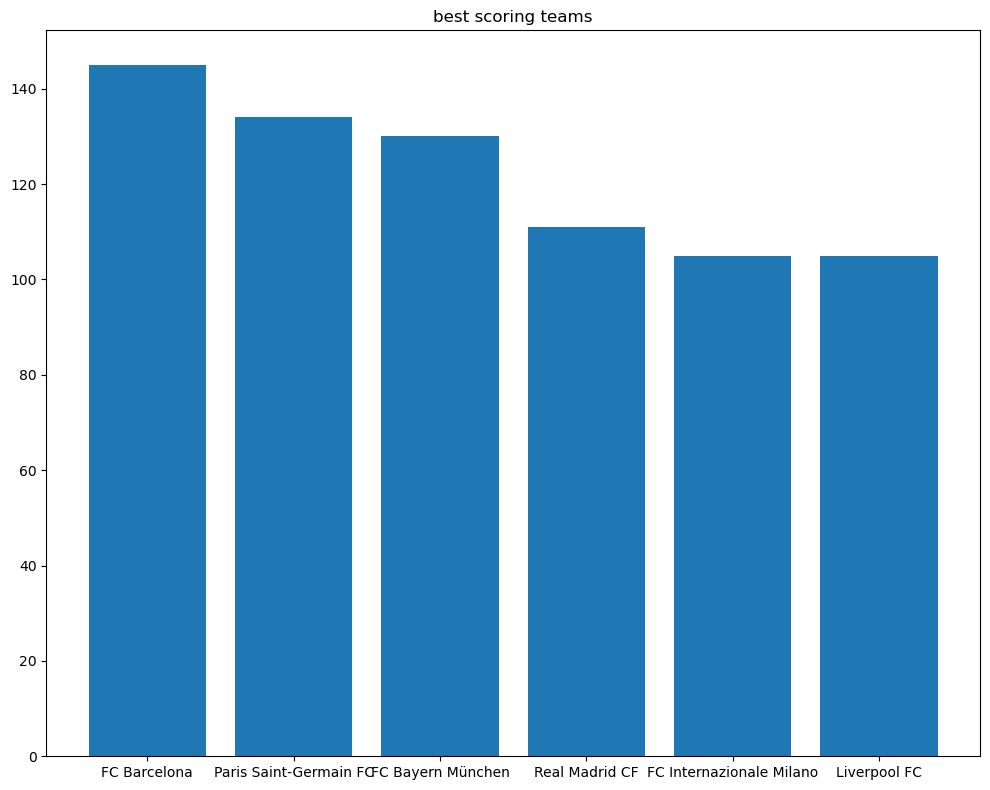

In [127]:
plt.figure(figsize=(10,8))
first_ten_teams = best_scoring_teams.sort_values(ascending=False).iloc[0:6]
plt.title("best scoring teams")
plt.bar(first_ten_teams.index,first_ten_teams.values)
plt.tight_layout()
plt.show()


### now we check if there is a relation between scoring goals and winning games

In [ ]:
comparaison = pd.concat([winning_teams_size,best_scoring_teams],axis=1)
comparaison.columns = ["wins","goals"]
print(comparaison.head())

                       wins  goals
1. FC Heidenheim 1846   8.0     37
1. FC Union Berlin     10.0     35
1. FSV Mainz 05        14.0     55
AC Milan               23.0     76
AC Monza                3.0     28


<Figure size 640x480 with 0 Axes>

### now we plot

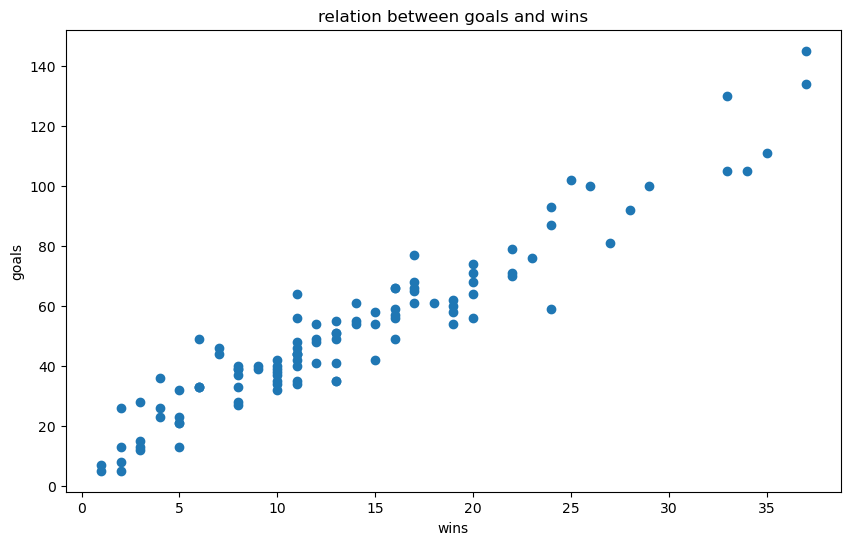

In [141]:
plt.figure(figsize=(10,6))
plt.scatter(comparaison["wins"],comparaison["goals"])
plt.title("relation between goals and wins")
plt.xlabel("wins")
plt.ylabel("goals")
plt.show()